In [1]:
# Cell 1 – Imports & setup
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

PATH = "/Users/gloriaso/Desktop/BME499/NeuroCTA/results/summary.json"
with open(PATH) as f:
    data = json.load(f)

mean_data = data["mean"]
labels = sorted(mean_data.keys(), key=lambda x: int(x))

LABELS = {
    "1":"BA","2":"R-P1P2","3":"L-P1P2","4":"R-ICA","5":"R-M1","6":"L-ICA",
    "7":"L-M1","8":"R-Pcom","9":"L-Pcom","10":"Acom","11":"R-A1A2","12":"L-A1A2",
    "13":"R-A3","14":"L-A3","15":"3rd-A2","16":"3rd-A3","17":"R-M2","18":"R-M3",
    "19":"L-M2","20":"L-M3","21":"R-P3P4","22":"L-P3P4","23":"R-VA","24":"L-VA",
    "25":"R-SCA","26":"L-SCA","27":"R-AICA","28":"L-AICA","29":"R-PICA","30":"L-PICA",
    "31":"R-AChA","32":"L-AChA","33":"R-OA","34":"L-OA","35":"VoG","36":"StS",
    "37":"ICVs","38":"R-BVR","39":"L-BVR","40":"SSS",
}

# Build per-case dict: short name -> {class -> Dice}
cases = {}
for entry in data["metric_per_case"]:
    name = entry["prediction_file"].split("/")[-1].replace(".nii.gz", "")
    cases[name] = {
        cls: entry["metrics"][cls]["Dice"]
        for cls in entry["metrics"]
        if entry["metrics"][cls]["n_ref"] > 0
        and entry["metrics"][cls]["Dice"] == entry["metrics"][cls]["Dice"]  # drop NaN
    }

def safe(v):
    try: return float(v)
    except: return np.nan

def dice_color(v):
    if np.isnan(v): return '#aaa'
    if v >= 0.7:    return '#2ecc71'
    if v >= 0.4:    return '#f39c12'
    return '#e74c3c'

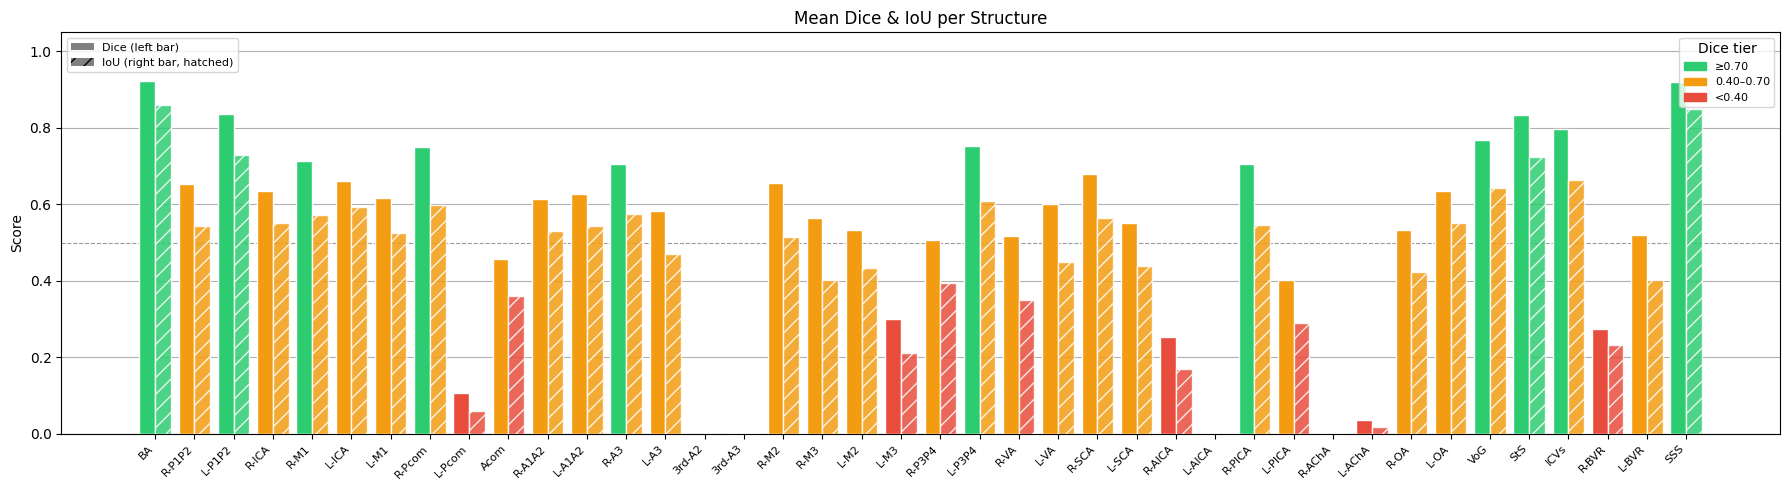

In [20]:
fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(x - w/2, dice_vals, w, color=[dice_color(v) for v in dice_vals], edgecolor='white', label='Dice', zorder=3)
ax.bar(x + w/2, iou_vals,  w, color=[dice_color(v) for v in iou_vals],  edgecolor='white', label='IoU', zorder=3, hatch='//', alpha=0.85)

ax.axhline(0.5, color='black', lw=0.8, ls='--', alpha=0.4)
ax.set_xticks(x)
ax.set_xticklabels([LABELS.get(l, l) for l in labels], fontsize=8, rotation=45, ha='right')
ax.set_ylabel('Score'); ax.set_ylim(0, 1.05)
ax.set_title('Mean Dice & IoU per Structure')
ax.grid(axis='y', zorder=0)

# Two separate legends
tier_legend = [mpatches.Patch(color='#2ecc71', label='≥0.70'),
               mpatches.Patch(color='#f39c12', label='0.40–0.70'),
               mpatches.Patch(color='#e74c3c', label='<0.40')]
l1 = ax.legend(handles=tier_legend, loc='upper right', title='Dice tier', fontsize=8)

metric_legend = [mpatches.Patch(facecolor='gray', label='Dice (left bar)'),
                 mpatches.Patch(facecolor='gray', hatch='//', label='IoU (right bar, hatched)')]
ax.legend(handles=metric_legend, loc='upper left', fontsize=8)
ax.add_artist(l1)  # re-add first legend since second call overwrites it

plt.tight_layout()
plt.show()

/var/folders/_p/8prncmms3szfhsh2frwb6tnm0000gn/T/ipykernel_97284/3737766902.py:56: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = plt.Rectangle((j - 0.6, 0.1), 0.3, 0.8,
/var/folders/_p/8prncmms3szfhsh2frwb6tnm0000gn/T/ipykernel_97284/3737766902.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


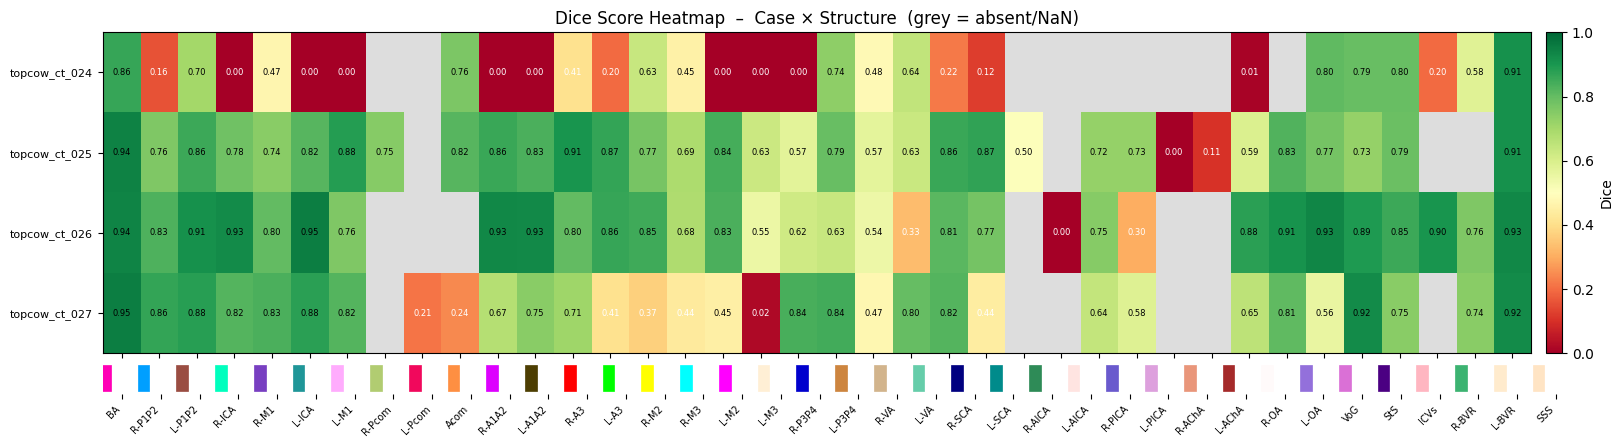

In [19]:
# Cell 3 – Dice heatmap: case × structure (coloured square boxes on x-axis)
SEG_COLORS = {
    "1": (255,0,182),   "2": (0,159,255),   "3": (154,77,66),   "4": (0,255,190),
    "5": (120,63,193),  "6": (31,150,152),  "7": (255,172,253), "8": (177,204,113),
    "9": (241,8,92),    "10": (254,143,66), "11": (221,0,255),  "12": (77,62,2),
    "13": (255,0,0),    "14": (0,255,0),    "15": (2,173,36),   "16": (0,0,255),
    "17": (255,255,0),  "18": (0,255,255),  "19": (255,0,255),  "20": (255,239,213),
    "21": (0,0,205),    "22": (205,133,63), "23": (210,180,140),"24": (102,205,170),
    "25": (0,0,128),    "26": (0,139,139),  "27": (46,139,87),  "28": (255,228,225),
    "29": (106,90,205), "30": (221,160,221),"31": (233,150,122),"32": (165,42,42),
    "33": (255,250,250),"34": (147,112,219),"35": (218,112,214),"36": (75,0,130),
    "37": (255,182,193),"38": (60,179,113), "39": (255,235,205),"40": (255,228,196),
}

all_classes = sorted({c for case in cases.values() for c in case}, key=int)
case_names  = list(cases.keys())
matrix = np.full((len(case_names), len(all_classes)), np.nan)
for i, cn in enumerate(case_names):
    for j, cl in enumerate(all_classes):
        if cl in cases[cn]:
            matrix[i, j] = cases[cn][cl]

# Two rows: heatmap on top, colour swatches on bottom
fig, (ax, ax_swatch) = plt.subplots(
    2, 1,
    figsize=(max(14, len(all_classes) * 0.5), max(3, len(case_names) * 0.8 + 1.5)),
    gridspec_kw={'height_ratios': [len(case_names), 0.4], 'hspace': 0.05}
)

cmap = plt.cm.RdYlGn
cmap.set_bad('#ddd')
im = ax.imshow(matrix, aspect='auto', cmap=cmap, vmin=0, vmax=1, interpolation='nearest')
ax.set_xticks(range(len(all_classes)))
ax.set_xticklabels([])   # labels go on swatch axis instead
ax.set_yticks(range(len(case_names)))
ax.set_yticklabels(case_names, fontsize=8)
ax.set_title('Dice Score Heatmap  –  Case × Structure  (grey = absent/NaN)')

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        v = matrix[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=6, color='black' if v > 0.45 else 'white')

plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01, label='Dice')

# Swatch row: one coloured square per class
ax_swatch.set_xlim(-0.5, len(all_classes) - 0.5)
ax_swatch.set_ylim(0, 1)
ax_swatch.set_yticks([])
ax_swatch.spines[['top','right','left','bottom']].set_visible(False)

for j, cl in enumerate(all_classes):
    r, g, b = [v/255 for v in SEG_COLORS.get(cl, (200,200,200))]
    rect = plt.Rectangle((j - 0.6, 0.1), 0.3, 0.8,
                      color=(r, g, b), linewidth=0.5, edgecolor='#888')
    ax_swatch.add_patch(rect)

ax_swatch.set_xticks(range(len(all_classes)))
ax_swatch.set_xticklabels([LABELS.get(c, c) for c in all_classes], fontsize=7, rotation=45, ha='right')

plt.tight_layout()
plt.show()

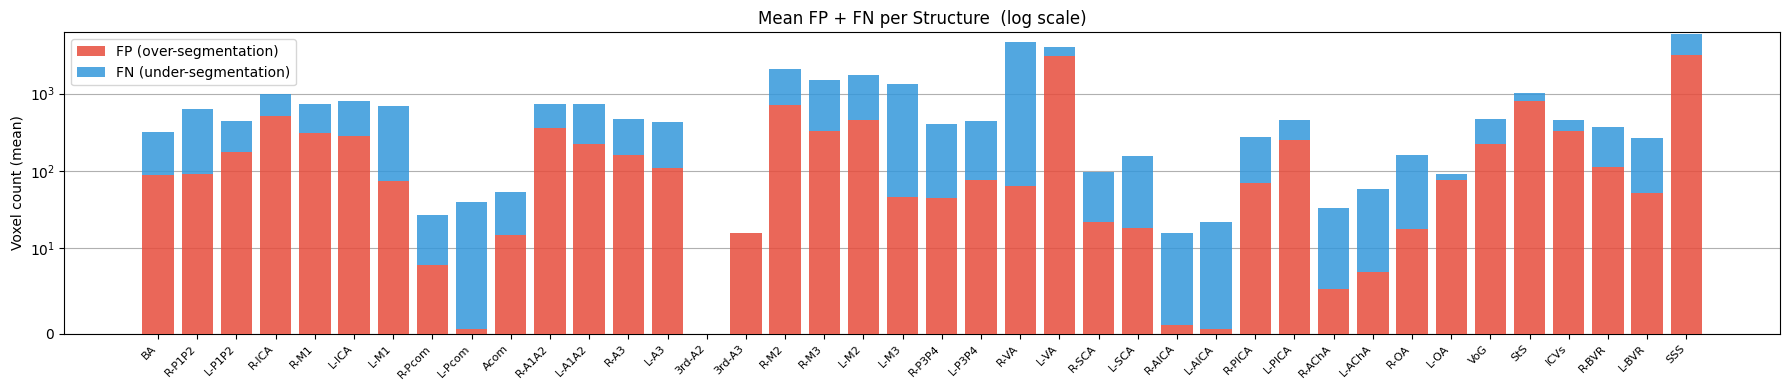

In [4]:
# Cell 4 – Mean FP & FN per structure
fp_arr = np.array([safe(mean_data[l].get('FP', 0)) for l in labels])
fn_arr = np.array([safe(mean_data[l].get('FN', 0)) for l in labels])
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(18, 4))
ax.bar(x, fp_arr, label='FP (over-segmentation)',  color='#e74c3c', alpha=0.85, zorder=3)
ax.bar(x, fn_arr, bottom=fp_arr, label='FN (under-segmentation)', color='#3498db', alpha=0.85, zorder=3)
ax.set_xticks(x)
ax.set_xticklabels([LABELS.get(l, l) for l in labels], fontsize=8, rotation=45, ha='right')
ax.set_ylabel('Voxel count (mean)')
ax.set_yscale('symlog', linthresh=10)
ax.set_title('Mean FP + FN per Structure  (log scale)')
ax.legend()
ax.grid(axis='y', zorder=0)
plt.tight_layout()
plt.show()

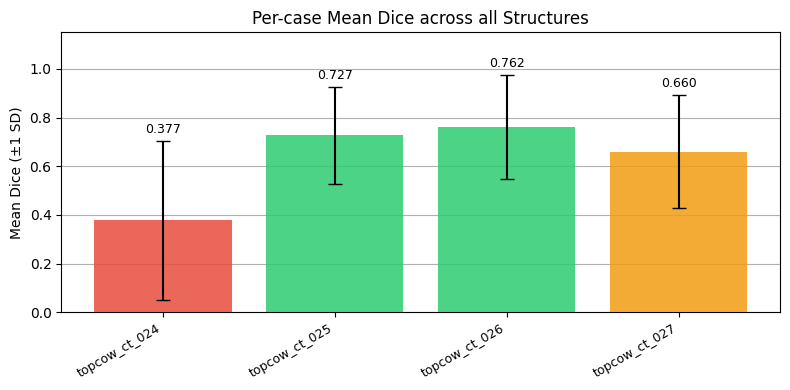

In [5]:
# Cell 5 – Per-case mean Dice
case_names = list(cases.keys())
means  = [np.nanmean(list(v.values())) for v in cases.values()]
stds   = [np.nanstd(list(v.values()))  for v in cases.values()]
xs     = np.arange(len(case_names))
colors = [dice_color(m) for m in means]

fig, ax = plt.subplots(figsize=(max(8, len(case_names) * 1.5), 4))
ax.bar(xs, means, color=colors, edgecolor='none', alpha=0.85, zorder=3)
ax.errorbar(xs, means, yerr=stds, fmt='none', color='black', capsize=5, lw=1.5, zorder=4)
for xi, (m, s) in enumerate(zip(means, stds)):
    ax.text(xi, m + s + 0.02, f'{m:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(xs)
ax.set_xticklabels(case_names, fontsize=9, rotation=30, ha='right')
ax.set_ylim(0, 1.15)
ax.set_ylabel('Mean Dice (±1 SD)')
ax.set_title('Per-case Mean Dice across all Structures')
ax.grid(axis='y', zorder=0)
plt.tight_layout()
plt.show()